# Importing modules and settings

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
from matplotlib.pyplot import rc_context

In [3]:
umap_cmap = sb.blend_palette(['xkcd:light grey', 'xkcd:medium blue'], as_cmap = True)

In [4]:
score_cmap = sb.blend_palette(['whitesmoke', 'lightgray', 'lightcoral', 'red'], as_cmap = True)

General settings of Scanpy

In [5]:
sc.settings.verbosity = 4
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

scanpy==1.9.1 anndata==0.9.1 umap==0.5.3 numpy==1.21.5 scipy==1.7.3 pandas==1.4.2 scikit-learn==1.0.2 statsmodels==0.13.2 python-igraph==0.9.11 pynndescent==0.5.7


# Declaring the input and output files

In [6]:
adata = sc.read_h5ad('../1 Matrix Preprocessing/Serotonergic_data_annotated.h5ad')

In [7]:
adata.var_names

Index(['h1SMcG0000008', 'h1SMcG0000009', 'h1SMcG0000011', 'h1SMcG0000012',
       'h1SMcG0000013', 'h1SMcG0000014', 'h1SMcG0000015', 'h1SMcG0000016',
       'h1SMcG0000017', 'h1SMcG0000021',
       ...
       'h1SMnG0034431', 'h1SMnG0034440', 'h1SMnG0034840', 'h1SMnG0034892',
       'h1SMnG0034949', 'h1SMnG0034970', 'h1SMnG0035064', 'h1SMnG0035227',
       'h1SMnG0035258', 'h1SMnG0035302'],
      dtype='object', length=24000)

In [8]:
adata.var

,gene_ids,feature_types,longest_isoform,gene_type,gene_JakkeGuo,gene_Jakke_ver1,gene_ddv6,jakkeguo_collapsed,jakke_ver1_collapsed,ddv6_collapsed,...,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std
h1SMcG0000008,h1SMcG0000008,Gene Expression,h1SMcT0000008.1,hconf,SMEST029651001.1,SMEST029651001.1,dd_Smed_v6_35379_0_1,"SMEST029651001.1,SMEST029651002.1,SmMSTRG.9911...","SMEST029651001.1,SMEST029651002.1",dd_Smed_v6_35379_0_1,...,10,0.000232,99.978886,11.0,True,0.000284,0.477953,1.455614,0.000172,0.012502
h1SMcG0000009,h1SMcG0000009,Gene Expression,h1SMcT0000009.2,hconf,SMEST029652002.1,SMEST029652002.1,dd_Smed_v6_5323_0_1,"SMEST029652002.1,SmMSTRG.9914.2,SmMSTRG.9914.3...",SMEST029652002.1,dd_Smed_v6_5323_0_1,...,196,0.004159,99.586175,197.0,True,0.003342,0.036366,0.147434,0.002345,0.039136
h1SMcG0000011,h1SMcG0000011,Gene Expression,h1SMcT0000011.1,hconf,SMEST029655001.1,SMEST029655001.1,dd_Smed_v6_6416_0_1,"SMEST029655001.1,SMEST029655002.1,SmMSTRG.9916...","SMEST029655001.1,SMEST029655002.1",dd_Smed_v6_6416_0_1,...,2366,0.053312,95.004539,2525.0,True,0.044958,0.140558,0.456098,0.031060,0.146029
h1SMcG0000012,h1SMcG0000012,Gene Expression,h1SMcT0000012.1,hconf,SmMSTRG.9913.2,SMEST029666001.1,dd_Smed_v6_20296_0_1,"SMEST029666001.1,SmMSTRG.9913.2",SMEST029666001.1,dd_Smed_v6_20296_0_1,...,25,0.000549,99.947216,26.0,True,0.000470,0.185634,0.589633,0.000318,0.015024
h1SMcG0000013,h1SMcG0000013,Gene Expression,h1SMcT0000013.5,hconf,SmMSTRG.9917.1,MSTRG.9917.1,dd_Smed_v6_4708_0_1,"SMEST029667004.1,SmMSTRG.9917.1,SmMSTRG.9917.2...","MSTRG.9917.1,SMEST029667004.1",dd_Smed_v6_4708_0_1,...,681,0.014885,98.562169,705.0,True,0.012562,0.100089,0.336211,0.008670,0.077038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
h1SMnG0034970,h1SMnG0034970,Gene Expression,h1SMnT0034970.1,other,-,-,-,-,-,-,...,2,0.000042,99.995777,2.0,True,0.000040,0.120145,0.395626,0.000027,0.004380
h1SMnG0035064,h1SMnG0035064,Gene Expression,h1SMnT0035064.1,other,-,-,-,-,-,-,...,1,0.000021,99.997889,1.0,True,0.000026,0.225550,0.707884,0.000017,0.003735
h1SMnG0035227,h1SMnG0035227,Gene Expression,h1SMnT0035227.1,other,-,-,-,-,-,-,...,2,0.000042,99.995777,2.0,True,0.000049,0.321466,0.992030,0.000031,0.005060
h1SMnG0035258,h1SMnG0035258,Gene Expression,h1SMnT0035258.1,hconf,-,-,-,-,-,-,...,3,0.000063,99.993666,3.0,True,0.000092,0.375602,1.152403,0.000057,0.007119


In [9]:
adata.obs

,sample,biological_rep,technical_rep,library,sample_bio,unique,sample_rep,unique_rep,n_counts,n_genes,...,pct_counts_mt,leiden_1,leiden_2,leiden_3,leiden_4,ingest_names,transferred,leiden_3_names_collapsed,leiden_3_names,broad_names
L43_1_AACCATTGGAGACTAGTAACGCTCGA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,148.0,130,...,0.0,8,9,7,25,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,parenchymal
L43_1_CATTCGACGGAGATCGCACGCTGATC,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,176.0,159,...,0.0,1,1,1,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons
L43_1_ACGGAGGCGGTGGAACAATAGGATGA,gfp(RNAi),B2,T1,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib1,502.0,359,...,0.0,0,0,0,7,neoblasts 1,neoblasts 1,neoblasts,neoblasts 1,neoblasts
L43_1_GACCTTGATAACGCTCGACAAGACTA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,185.0,149,...,0.0,4,3,9,5,early epidermal progenitors,early epidermal progenitors,early epidermal progenitors 1,early epidermal progenitors 1,epidermal
L43_1_TTACCTCGACTGGAACAAAGATCGCA,lhx1/5-1(RNAi),B1,T2,Lib1,lhx1/5-1(RNAi)_B1,lhx1/5-1(RNAi)_Lib1,lhx1/5-1(RNAi)_B1_T2,lhx1/5-1(RNAi)_B1_T2_Lib1,180.0,166,...,0.0,2,6,3,9,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,muscle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,411.0,212,...,0.0,7,37,26,49,epidermis,epidermis,epidermis 2,epidermis 2,epidermal
L43_5_GGTACCGGCAGAATCTGATGAAGAGA,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,262.0,186,...,0.0,0,0,5,4,neoblasts 1,neoblasts 1,neoblasts,neoblasts 3,neoblasts
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA,gfp(RNAi),B1,T2,Lib5,gfp(RNAi)_B1,gfp(RNAi)_Lib5,gfp(RNAi)_B1_T2,gfp(RNAi)_B1_T2_Lib5,110.0,103,...,0.0,5,8,6,3,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,parenchymal
L43_5_CCAGTTCCAATGGAACAAATTGGCTC,gfp(RNAi),B2,T1,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib5,238.0,201,...,0.0,1,1,1,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons


In [10]:
adata

AnnData object with n_obs × n_vars = 47292 × 24000
    obs: 'sample', 'biological_rep', 'technical_rep', 'library', 'sample_bio', 'unique', 'sample_rep', 'unique_rep', 'n_counts', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4', 'ingest_names', 'transferred', 'leiden_3_names_collapsed', 'leiden_3_names', 'broad_names'
    var: 'gene_ids', 'feature_types', 'longest_isoform', 'gene_type', 'gene_JakkeGuo', 'gene_Jakke_ver1', 'gene_ddv6', 'jakkeguo_collapsed', 'jakke_ver1_collapsed', 'ddv6_collapsed', 'Preferred_name', 'Description', 'PFAMs', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'biological_replicates', 'dendrogram_leiden_1', 'dendrogram_leiden_2', 'dendrogram_leiden_3', 'dendrogram_leiden_4', 'hvg', 'ingest_names_colors', 'leiden', 'leiden_1_colors', 'leiden_2_colors', 'leiden_

In [11]:
clusteringlayer = 'leiden_3_names'

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


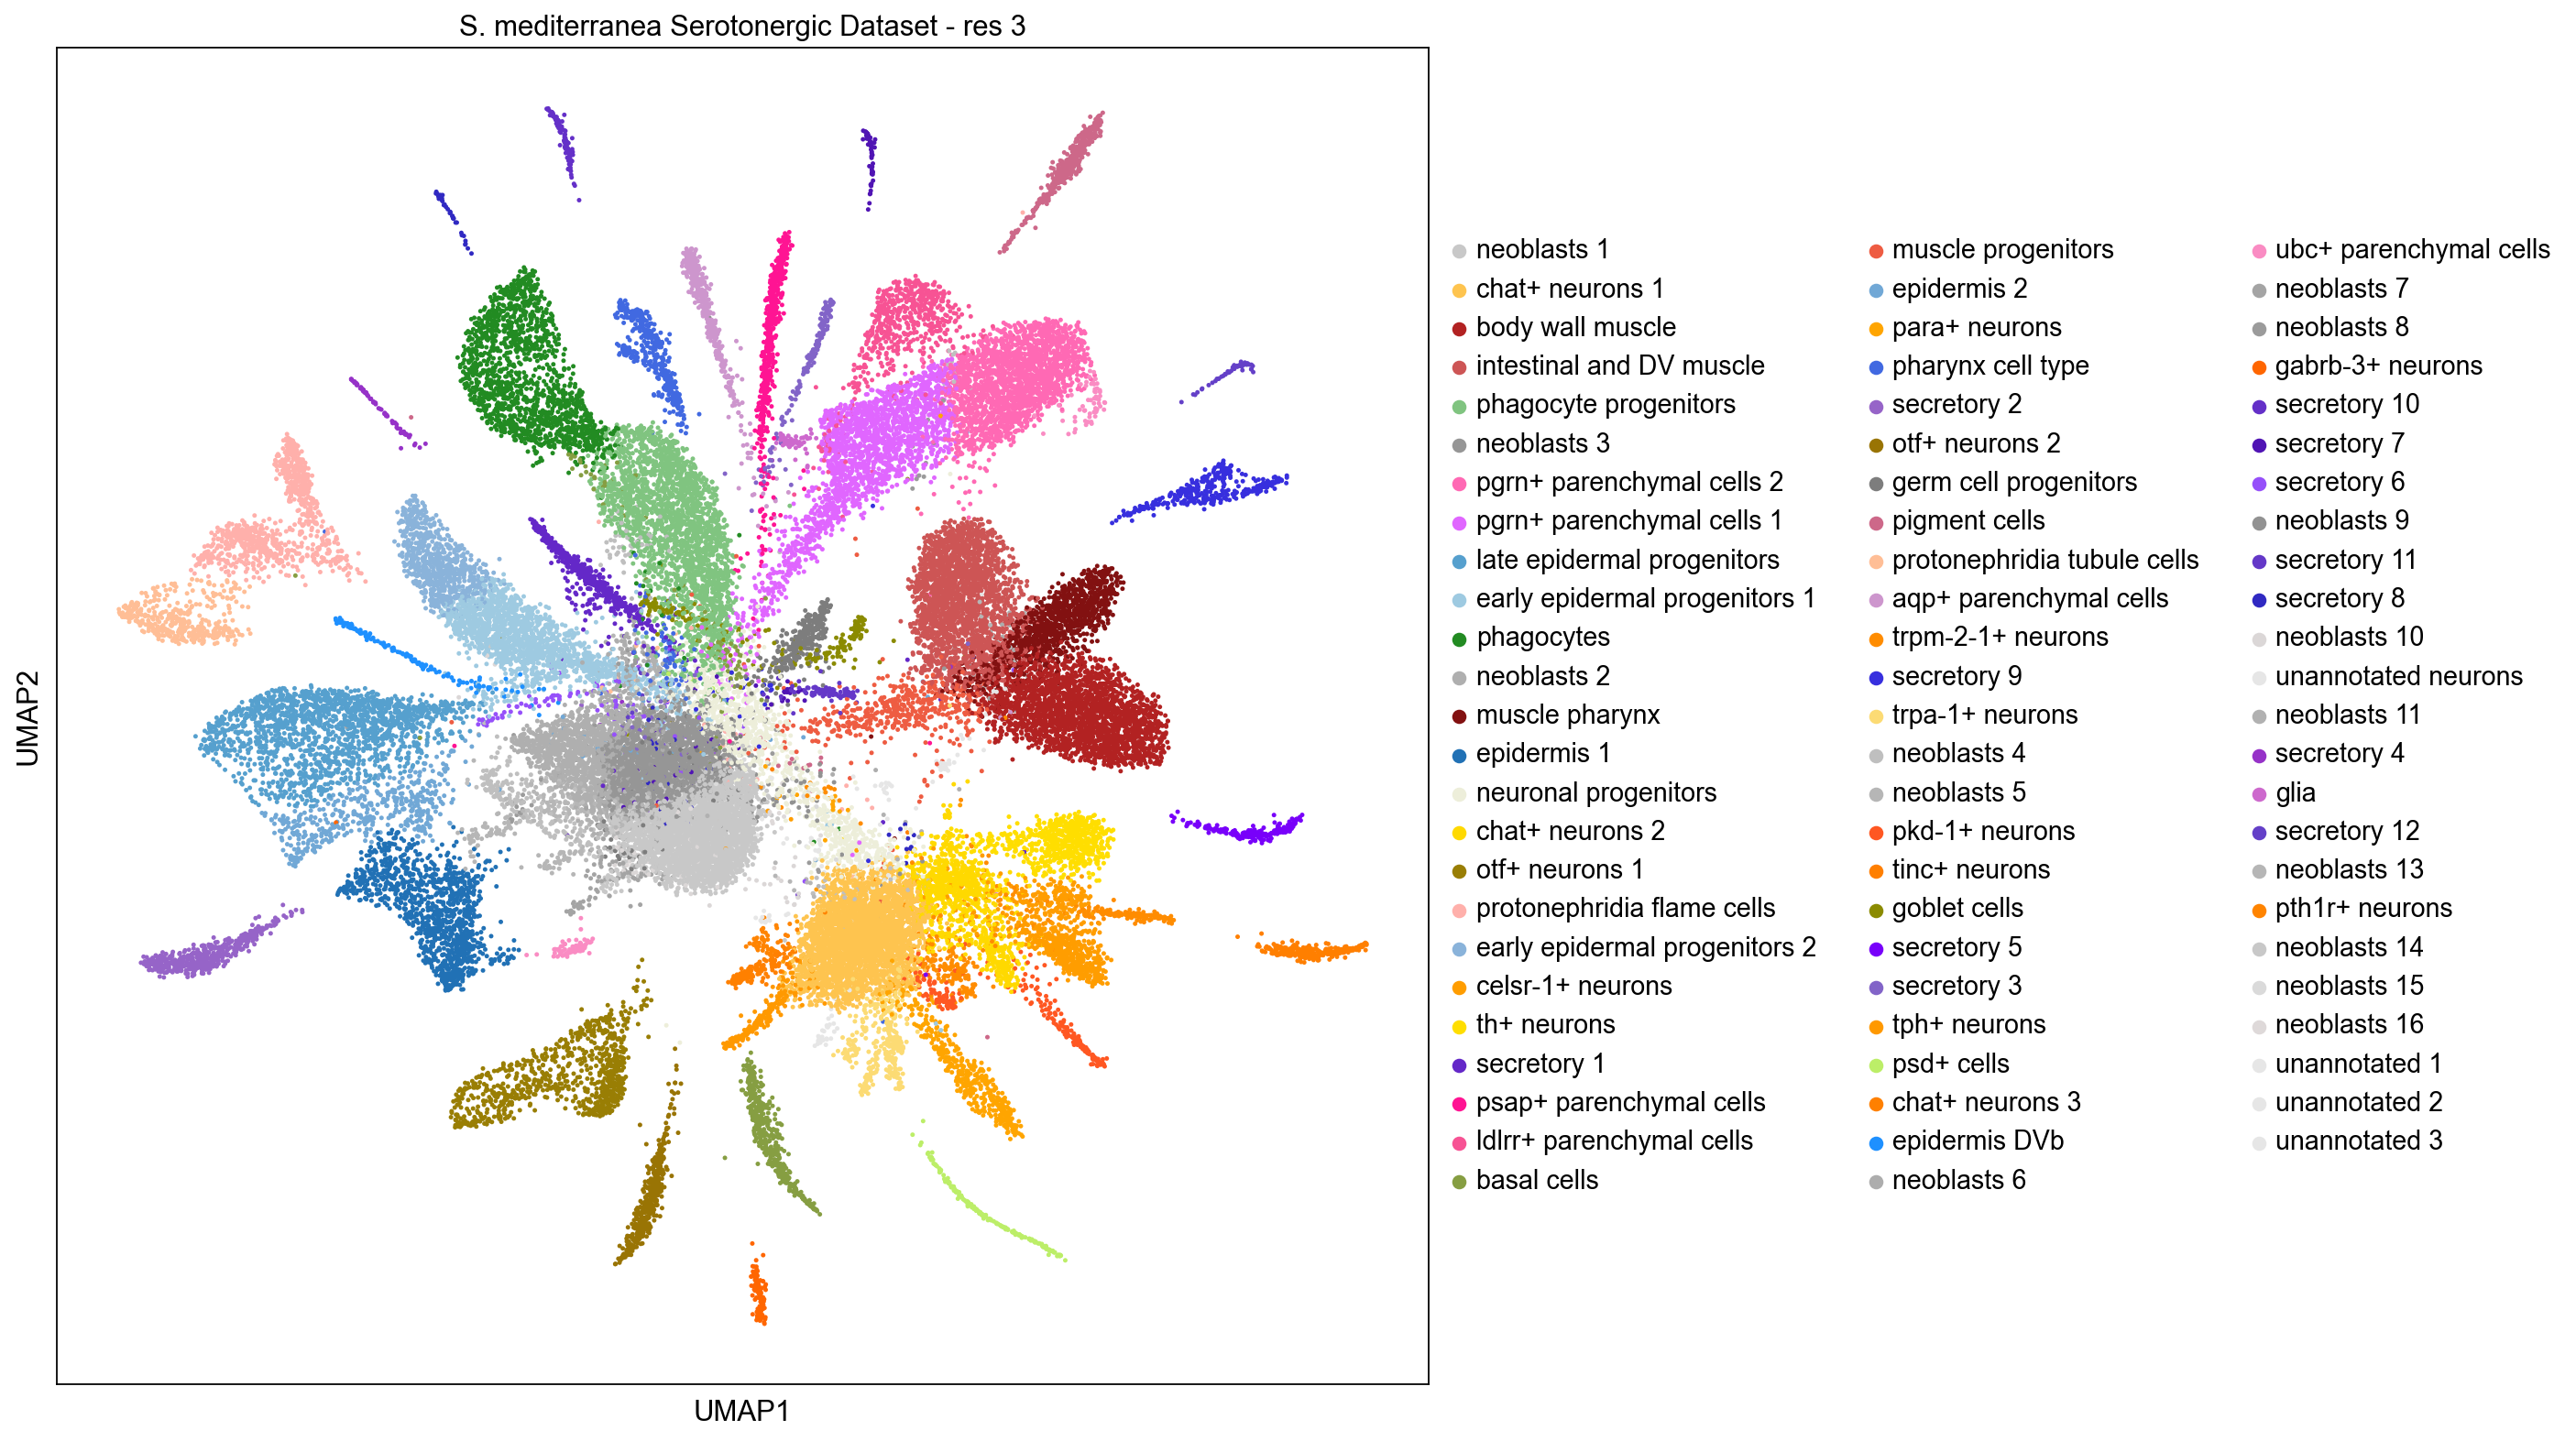

In [12]:
with rc_context({'figure.figsize': (12, 12)}):
    sc.pl.umap(adata, color=clusteringlayer, legend_fontoutline = 5,
        title= 'S. mediterranea Serotonergic Dataset - res 3', size = 20,     
        frameon=True, add_outline = False)

C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


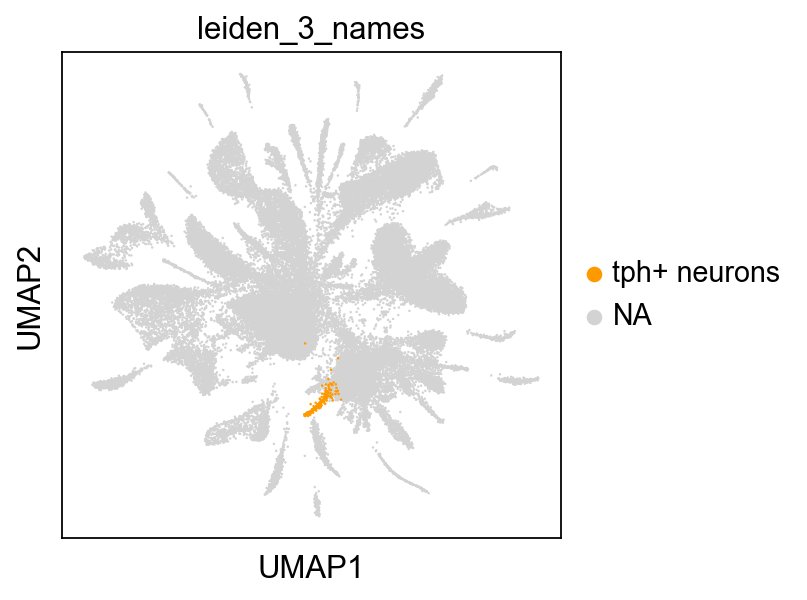

In [13]:
sc.pl.umap(adata, color= clusteringlayer, size = 5, groups = 
           ['tph+ neurons'])

**smed_genes_annotated_with_sero_GOs**

In [14]:
sero_GOs = ["h1SMcG0000075",
"h1SMcG0000511",
"h1SMcG0000518",
"h1SMcG0000627",
"h1SMcG0000639",
"h1SMcG0000646",
"h1SMcG0000648",
"h1SMcG0000652",
"h1SMcG0000653",
"h1SMcG0000658",
"h1SMcG0000772",
"h1SMcG0001077",
"h1SMcG0001109",
"h1SMcG0001240",
"h1SMcG0001298",
"h1SMcG0001325",
"h1SMcG0001346",
"h1SMcG0001741",
"h1SMcG0001780",
"h1SMcG0001803",
"h1SMcG0001890",
"h1SMcG0002059",
"h1SMcG0002172",
"h1SMcG0002255",
"h1SMcG0002311",
"h1SMcG0002434",
"h1SMcG0002506",
"h1SMcG0002584",
"h1SMcG0002796",
"h1SMcG0002950",
"h1SMcG0003020",
"h1SMcG0003199",
"h1SMcG0003214",
"h1SMcG0003223",
"h1SMcG0003358",
"h1SMcG0003411",
"h1SMcG0003461",
"h1SMcG0003595",
"h1SMcG0003596",
"h1SMcG0003703",
"h1SMcG0003705",
"h1SMcG0003707",
"h1SMcG0003784",
"h1SMcG0003850",
"h1SMcG0004060",
"h1SMcG0004083",
"h1SMcG0004100",
"h1SMcG0004442",
"h1SMcG0004481",
"h1SMcG0004608",
"h1SMcG0004699",
"h1SMcG0004837",
"h1SMcG0004882",
"h1SMcG0004950",
"h1SMcG0004988",
"h1SMcG0005082",
"h1SMcG0005186",
"h1SMcG0005243",
"h1SMcG0005297",
"h1SMcG0005337",
"h1SMcG0005489",
"h1SMcG0005856",
"h1SMcG0005863",
"h1SMcG0005933",
"h1SMcG0005934",
"h1SMcG0005940",
"h1SMcG0006077",
"h1SMcG0006225",
"h1SMcG0006226",
"h1SMcG0006227",
"h1SMcG0006272",
"h1SMcG0006322",
"h1SMcG0006351",
"h1SMcG0006353",
"h1SMcG0006390",
"h1SMcG0006581",
"h1SMcG0006614",
"h1SMcG0006833",
"h1SMcG0006841",
"h1SMcG0006960",
"h1SMcG0006969",
"h1SMcG0007028",
"h1SMcG0007060",
"h1SMcG0007066",
"h1SMcG0007206",
"h1SMcG0007578",
"h1SMcG0007585",
"h1SMcG0007645",
"h1SMcG0007668",
"h1SMcG0007671",
"h1SMcG0007672",
"h1SMcG0007847",
"h1SMcG0007883",
"h1SMcG0007985",
"h1SMcG0008063",
"h1SMcG0008069",
"h1SMcG0008070",
"h1SMcG0008071",
"h1SMcG0008073",
"h1SMcG0008074",
"h1SMcG0008123",
"h1SMcG0008200",
"h1SMcG0008305",
"h1SMcG0008434",
"h1SMcG0008491",
"h1SMcG0008783",
"h1SMcG0008877",
"h1SMcG0009233",
"h1SMcG0009255",
"h1SMcG0009256",
"h1SMcG0009460",
"h1SMcG0009644",
"h1SMcG0009845",
"h1SMcG0009847",
"h1SMcG0009855",
"h1SMcG0010029",
"h1SMcG0010038",
"h1SMcG0010071",
"h1SMcG0010087",
"h1SMcG0010163",
"h1SMcG0010263",
"h1SMcG0010304",
"h1SMcG0010517",
"h1SMcG0010528",
"h1SMcG0010639",
"h1SMcG0010691",
"h1SMcG0010915",
"h1SMcG0010985",
"h1SMcG0011069",
"h1SMcG0011279",
"h1SMcG0011331",
"h1SMcG0011433",
"h1SMcG0011524",
"h1SMcG0011693",
"h1SMcG0011700",
"h1SMcG0011954",
"h1SMcG0012005",
"h1SMcG0012721",
"h1SMcG0012828",
"h1SMcG0012917",
"h1SMcG0012986",
"h1SMcG0013018",
"h1SMcG0013103",
"h1SMcG0013104",
"h1SMcG0013116",
"h1SMcG0013119",
"h1SMcG0013156",
"h1SMcG0013358",
"h1SMcG0013420",
"h1SMcG0013445",
"h1SMcG0013526",
"h1SMcG0013631",
"h1SMcG0013712",
"h1SMcG0013766",
"h1SMcG0013792",
"h1SMcG0013796",
"h1SMcG0014164",
"h1SMcG0014261",
"h1SMcG0014386",
"h1SMcG0014466",
"h1SMcG0014509",
"h1SMcG0014535",
"h1SMcG0014586",
"h1SMcG0014639",
"h1SMcG0014721",
"h1SMcG0015011",
"h1SMcG0015024",
"h1SMcG0015027",
"h1SMcG0015164",
"h1SMcG0015186",
"h1SMcG0015224",
"h1SMcG0015279",
"h1SMcG0015359",
"h1SMcG0015456",
"h1SMcG0015541",
"h1SMcG0015590",
"h1SMcG0015606",
"h1SMcG0015663",
"h1SMcG0015757",
"h1SMcG0015764",
"h1SMcG0015771",
"h1SMcG0015867",
"h1SMcG0015934",
"h1SMcG0016145",
"h1SMcG0016343",
"h1SMcG0016430",
"h1SMcG0016486",
"h1SMcG0016511",
"h1SMcG0016513",
"h1SMcG0016516",
"h1SMcG0016545",
"h1SMcG0016700",
"h1SMcG0016738",
"h1SMcG0016841",
"h1SMcG0016892",
"h1SMcG0016984",
"h1SMcG0017016",
"h1SMcG0017047",
"h1SMcG0017191",
"h1SMcG0017200",
"h1SMcG0017204",
"h1SMcG0017508",
"h1SMcG0017534",
"h1SMcG0017653",
"h1SMcG0017750",
"h1SMcG0017864",
"h1SMcG0017880",
"h1SMcG0018230",
"h1SMcG0018256",
"h1SMcG0018398",
"h1SMcG0018436",
"h1SMcG0018710",
"h1SMcG0018711",
"h1SMcG0018719",
"h1SMcG0018720",
"h1SMcG0018728",
"h1SMcG0018832",
"h1SMcG0018854",
"h1SMcG0019074",
"h1SMcG0019090",
"h1SMcG0019152",
"h1SMcG0019186",
"h1SMcG0019219",
"h1SMcG0019443",
"h1SMcG0019456",
"h1SMcG0019484",
"h1SMcG0019612",
"h1SMcG0019646",
"h1SMcG0019737",
"h1SMcG0019914",
"h1SMcG0020058",
"h1SMcG0020249",
"h1SMcG0020280",
"h1SMcG0020286",
"h1SMcG0020399",
"h1SMcG0020432",
"h1SMcG0020440",
"h1SMcG0020441",
"h1SMcG0020443",
"h1SMcG0020445",
"h1SMcG0020446",
"h1SMcG0020447",
"h1SMcG0020539",
"h1SMcG0020690",
"h1SMcG0020742",
"h1SMcG0020795",
"h1SMcG0020845",
"h1SMcG0021033",
"h1SMcG0021062",
"h1SMcG0021113",
"h1SMcG0021365",
"h1SMcG0021492",
"h1SMcG0021502",
"h1SMcG0021690",
"h1SMcG0021906",
"h1SMcG0022047",
"h1SMcG0022104",
"h1SMcG0022111",
"h1SMcG0022183",
"h1SMcG0022351",
"h1SMcG0022433",
"h1SMcG0022449",
"h1SMcG0022709",
"h1SMcG0022895",
"h1SMcG0022994",
"h1SMcG0023031",
"h1SMcG0023032",
"h1SMnG0003087",
"h1SMnG0005594",
"h1SMnG0006085",
"h1SMnG0006515",
"h1SMnG0010676",
"h1SMnG0011750",
"h1SMnG0012862",
"h1SMnG0013228",
"h1SMnG0013476",
"h1SMnG0014677",
"h1SMnG0017569",
"h1SMnG0021444",
"h1SMnG0022536",
"h1SMnG0024514",
"h1SMnG0026723",
"h1SMnG0028754",
"h1SMnG0032237",
"h1SMnG0032243",
"h1SMnG0033548"
]

In [15]:
sc.tl.score_genes(adata, sero_GOs, ctrl_size= len(sero_GOs), gene_pool=None, n_bins=25, score_name='score_sero_GOs')

computing score 'score_sero_GOs'
    finished: added
    'score_sero_GOs', score of gene set (adata.obs).
    6816 total control genes are used. (0:00:00)


C:\Users\19125778\Anaconda3\lib\site-packages\scanpy\tools\_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


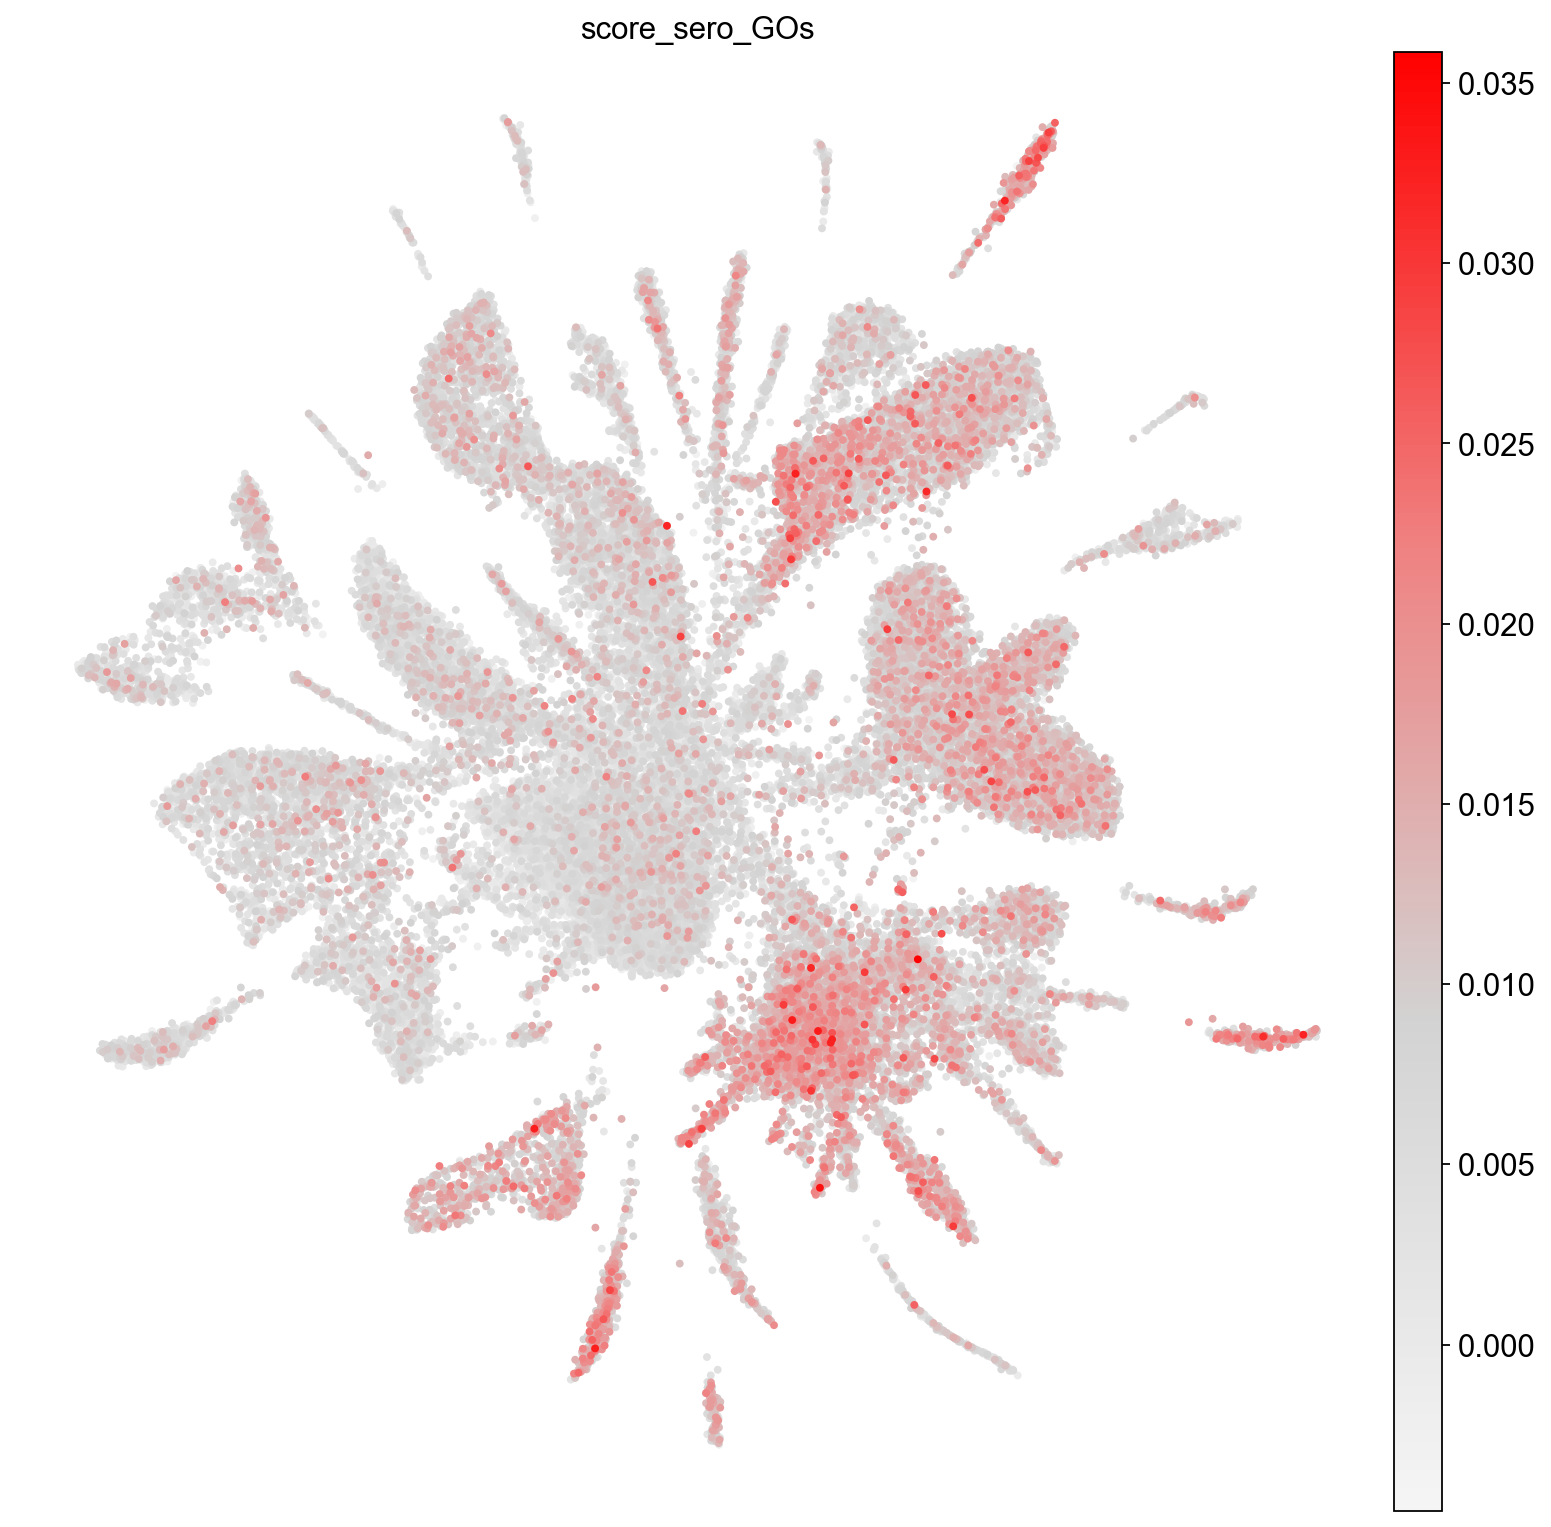

In [90]:
with rc_context({'figure.figsize': (12, 12)}):
    sc.pl.umap(adata, color= 'score_sero_GOs', color_map = score_cmap, size = 50, frameon = False, save = 'sero_GO_Score')

In [17]:
adata.obs

,sample,biological_rep,technical_rep,library,sample_bio,unique,sample_rep,unique_rep,n_counts,n_genes,...,leiden_1,leiden_2,leiden_3,leiden_4,ingest_names,transferred,leiden_3_names_collapsed,leiden_3_names,broad_names,score_sero_GOs
L43_1_AACCATTGGAGACTAGTAACGCTCGA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,148.0,130,...,8,9,7,25,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1,parenchymal,0.008361
L43_1_CATTCGACGGAGATCGCACGCTGATC,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,176.0,159,...,1,1,1,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons,0.020283
L43_1_ACGGAGGCGGTGGAACAATAGGATGA,gfp(RNAi),B2,T1,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib1,502.0,359,...,0,0,0,7,neoblasts 1,neoblasts 1,neoblasts,neoblasts 1,neoblasts,-0.000262
L43_1_GACCTTGATAACGCTCGACAAGACTA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,185.0,149,...,4,3,9,5,early epidermal progenitors,early epidermal progenitors,early epidermal progenitors 1,early epidermal progenitors 1,epidermal,0.003361
L43_1_TTACCTCGACTGGAACAAAGATCGCA,lhx1/5-1(RNAi),B1,T2,Lib1,lhx1/5-1(RNAi)_B1,lhx1/5-1(RNAi)_Lib1,lhx1/5-1(RNAi)_B1_T2,lhx1/5-1(RNAi)_B1_T2_Lib1,180.0,166,...,2,6,3,9,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,intestinal and DV muscle,muscle,0.004996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,411.0,212,...,7,37,26,49,epidermis,epidermis,epidermis 2,epidermis 2,epidermal,0.001508
L43_5_GGTACCGGCAGAATCTGATGAAGAGA,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,262.0,186,...,0,0,5,4,neoblasts 1,neoblasts 1,neoblasts,neoblasts 3,neoblasts,0.003157
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA,gfp(RNAi),B1,T2,Lib5,gfp(RNAi)_B1,gfp(RNAi)_Lib5,gfp(RNAi)_B1_T2,gfp(RNAi)_B1_T2_Lib5,110.0,103,...,5,8,6,3,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2,parenchymal,0.004031
L43_5_CCAGTTCCAATGGAACAAATTGGCTC,gfp(RNAi),B2,T1,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib5,238.0,201,...,1,1,1,0,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,chat+ neurons 1,neurons,0.008769


In [18]:
sc_cluster = pd.pivot_table(adata.obs[[clusteringlayer, 'score_sero_GOs']], index = clusteringlayer)

In [19]:
sc_cluster.index

CategoricalIndex(['neoblasts 1', 'chat+ neurons 1', 'body wall muscle',
                  'intestinal and DV muscle', 'phagocyte progenitors',
                  'neoblasts 3', 'pgrn+ parenchymal cells 2',
                  'pgrn+ parenchymal cells 1', 'late epidermal progenitors',
                  'early epidermal progenitors 1', 'phagocytes', 'neoblasts 2',
                  'muscle pharynx', 'epidermis 1', 'neuronal progenitors',
                  'chat+ neurons 2', 'otf+ neurons 1',
                  'protonephridia flame cells',
                  'early epidermal progenitors 2', 'celsr-1+ neurons',
                  'th+ neurons', 'secretory 1', 'psap+ parenchymal cells',
                  'ldlrr+ parenchymal cells', 'basal cells',
                  'muscle progenitors', 'epidermis 2', 'para+ neurons',
                  'pharynx cell type', 'secretory 2', 'otf+ neurons 2',
                  'germ cell progenitors', 'pigment cells',
                  'protonephridia tubule cells', 

In [20]:
sc_cluster['score_sero_GOs']

leiden_3_names
neoblasts 1                 0.002674
chat+ neurons 1             0.008889
body wall muscle            0.007411
intestinal and DV muscle    0.006159
phagocyte progenitors       0.004417
                              ...   
neoblasts 15                0.005077
neoblasts 16                0.002388
unannotated 1               0.007123
unannotated 2               0.006649
unannotated 3               0.009707
Name: score_sero_GOs, Length: 74, dtype: float64

In [21]:
sc_cluster

,score_sero_GOs
leiden_3_names,
neoblasts 1,0.002674
chat+ neurons 1,0.008889
body wall muscle,0.007411
intestinal and DV muscle,0.006159
phagocyte progenitors,0.004417
...,...
neoblasts 15,0.005077
neoblasts 16,0.002388
unannotated 1,0.007123


In [22]:
sc_cluster.loc['tph+ neurons']

score_sero_GOs    0.012328
Name: tph+ neurons, dtype: float64

In [23]:
sc_cluster.loc['otf+ neurons 1']

score_sero_GOs    0.009279
Name: otf+ neurons 1, dtype: float64

In [24]:
sc_cluster.loc['otf+ neurons 2']

score_sero_GOs    0.010573
Name: otf+ neurons 2, dtype: float64

In [25]:
sc_cluster.loc['pgrn+ parenchymal cells 1']

score_sero_GOs    0.00812
Name: pgrn+ parenchymal cells 1, dtype: float64

In [26]:
sc_cluster.loc['late epidermal progenitors']

score_sero_GOs    0.004692
Name: late epidermal progenitors, dtype: float64

In [27]:
sc_cluster.loc['intestinal and DV muscle']

score_sero_GOs    0.006159
Name: intestinal and DV muscle, dtype: float64

In [28]:
sc_cluster.loc['neoblasts 1']

score_sero_GOs    0.002674
Name: neoblasts 1, dtype: float64

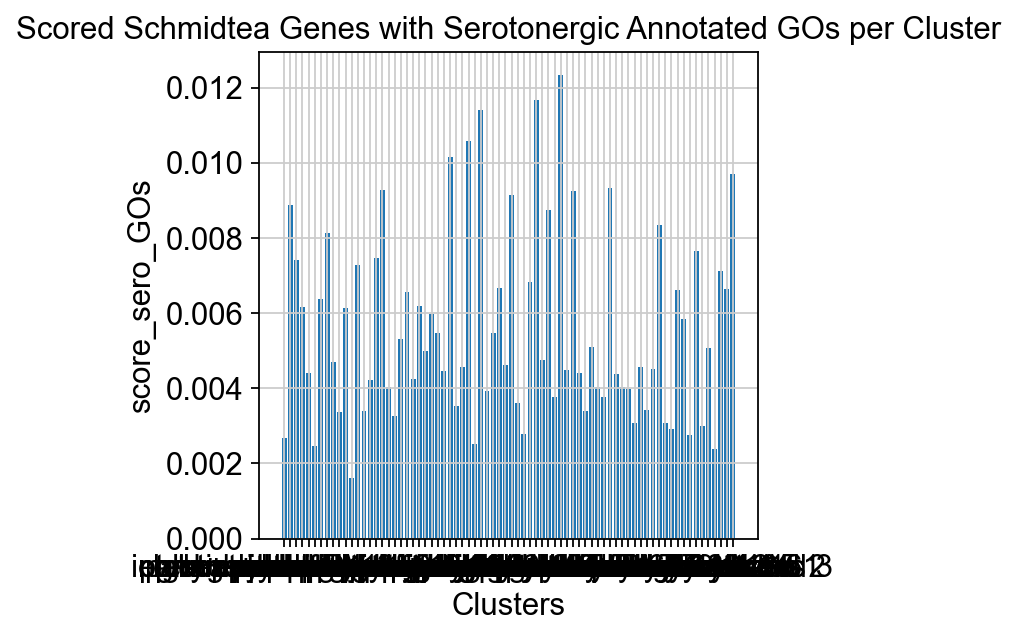

<Figure size 2400x2400 with 0 Axes>

In [29]:
categories = sc_cluster.index
values = sc_cluster['score_sero_GOs']

# Creating a bar plot
plt.bar(categories, values)

# Adding labels and title
plt.xlabel('Clusters')
plt.ylabel('score_sero_GOs')
plt.title('Scored Schmidtea Genes with Serotonergic Annotated GOs per Cluster')

# Displaying the plot
plt.figure(figsize=(30, 30))
plt.show()

In [30]:
sc_cluster_broad = pd.pivot_table(adata.obs[['broad_names', 'score_sero_GOs']], index = 'broad_names')

In [31]:
sc_cluster_broad

,score_sero_GOs
broad_names,
epidermal,0.003845
epidermis DVb,0.004411
muscle,0.006776
neoblasts,0.002746
neurons,0.008479
parenchymal,0.007039
phagocytes,0.005176
pharynx cell type,0.003531
protonephridia,0.004003


In [32]:
sc_cluster_broad.loc['neurons']

score_sero_GOs    0.008479
Name: neurons, dtype: float64

In [33]:
sc_cluster_broad.loc['parenchymal']

score_sero_GOs    0.007039
Name: parenchymal, dtype: float64

In [34]:
sc_cluster_broad.loc['muscle']

score_sero_GOs    0.006776
Name: muscle, dtype: float64

In [35]:
sc_cluster_broad.loc['neoblasts']

score_sero_GOs    0.002746
Name: neoblasts, dtype: float64

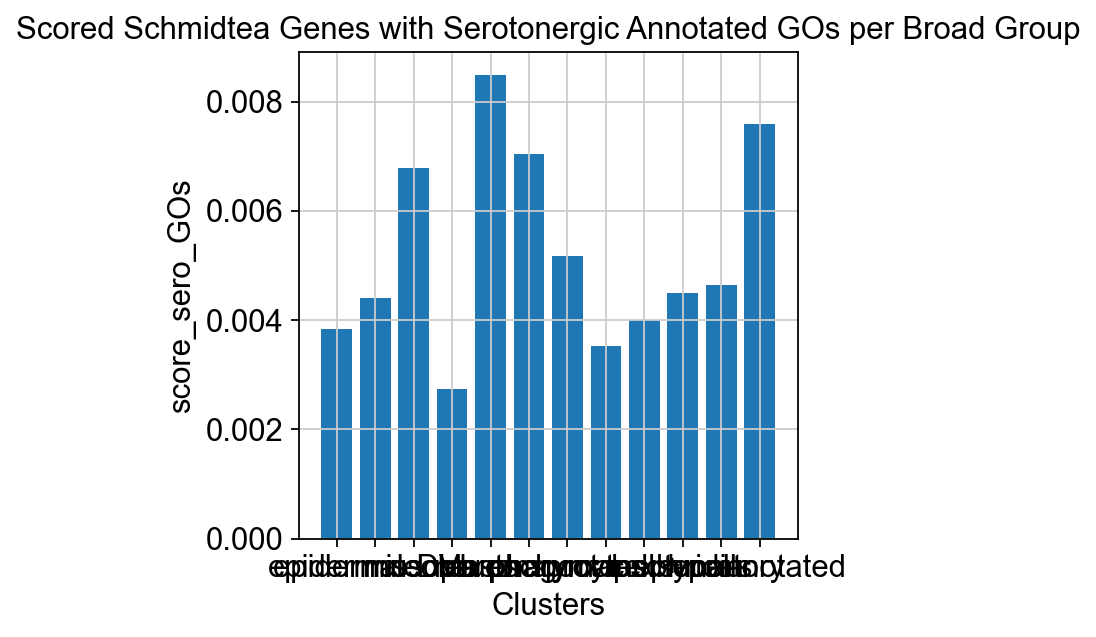

<Figure size 2400x2400 with 0 Axes>

In [36]:
categories = sc_cluster_broad.index
values = sc_cluster_broad['score_sero_GOs']

# Creating a bar plot
plt.bar(categories, values)

# Adding labels and title
plt.xlabel('Clusters')
plt.ylabel('score_sero_GOs')
plt.title('Scored Schmidtea Genes with Serotonergic Annotated GOs per Broad Group')

# Displaying the plot
plt.figure(figsize=(30, 30))
plt.show()


# Saving

In [83]:
sc_cluster.to_excel( './sc_cluster.xlsx')

In [84]:
sc_cluster_broad.to_excel( './sc_cluster_broad.xlsx')